In [ ]:
%pip install numpy pandas matplotlib yfinance
%pip install --upgrade pip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Daily log returns

We wish to calculate some basic financial quantities, like log returns and VaR (Value at Risk), assuming that the stock price is distributed log-normally. We begin by importing some data from yfinance.

In [11]:
ticker_name = 'AAPL'    # insert any ticker name here
data = yf.download(ticker_name, start='2020-01-01', end='2025-12-31')
data.index = pd.to_datetime(data.index)     # ensures that the index is in datetime format
data.columns = data.columns.droplevel('Ticker')    # renames the columns to remove the ticker name from the column names
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333847,72.394055,71.091154,71.344024,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


Next, we calculate the daily log returns, followed by their mean and standard deviation. In particular, the latter is evaluated as an unbiased estimator (using 1 degree of freedom).

In [15]:
data['log_return'] = np.log(data['Close'].shift(-1) / data['Close'])
mu = data['log_return'].mean()    # daily mean
sigma = data['log_return'].std(ddof=1)    # daily standard deviation

We want to plot the daily log returns as a histogram, and also include a plot of the fitted normal distribution. We use the scipy.stats package for it, to call the norm function.

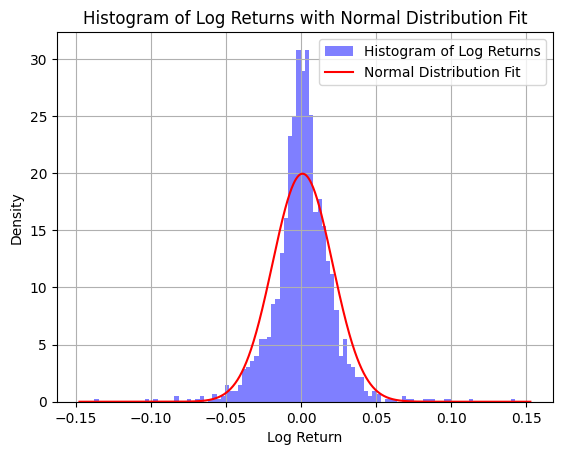

In [18]:
from scipy.stats import norm

data['log_return'].hist(bins=100, density=True, alpha=0.5, color='blue', label='Histogram of Log Returns')

x = np.linspace(data['log_return'].min()-0.01, data['log_return'].max()+0.01, 1000)
plt.plot(x,norm.pdf(x,mu,sigma), color='red', label='Normal Distribution Fit')

plt.title('Histogram of Log Returns with Normal Distribution Fit')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

### Estimating risky events

Now we calculate the probability of the stock price dropping by at least $x$ percentage in a single day. For example, when $x=0.1$, we are considering the case of the stock price decreasing by more than 10%. Thus, we have $S_1 \le (1-x)S_0$, where $S_t$ is the stock price on day $t$. Then, assuming that the returns are log-normally distributed,
$$N(\mu,\sigma^2) \sim \ln\left(\frac{S_t}{S_0}\right) \le \ln (1-x).$$

This means that $Z = \frac{\ln\left(\frac{S_t}{S_0}\right)-\mu}{\sigma}$ and $Z^* = \frac{\ln(1-x)-\mu}{\sigma}$ are both standard normal variables. What we are seeking is the probability $P(Z\le Z^*) = \Phi(Z^*)$, where $\Phi$ is the CDF of the standard normal distribution.

In [ ]:
x = 0.05    # percentage drop in stock price in a single day
z_score = (np.log(1-x) - mu) / sigma
print(f"The probability that the stock price drops by at least {x*100}% in a single day is: {norm.cdf(z_score)*100:.3f}%.")

The probability that the stock price drops by at least 5.0% in a single day is: 0.454%.


We can also use the independence of the stock price movements across different days to calculate the mean and standard deviation for annual log returns. Indeed, these are $\mu_{a} = 252\mu$ and $\sigma_{a} = \sqrt{252}\sigma$.

In [26]:
y = 0.05    # percentage drop in stock price across a 1-year period
trading_days = 252    # number of trading days in a year
mua = mu * trading_days    # annualized mean
sigmaa = sigma * np.sqrt(trading_days)    # annualized standard deviation
z_score_a = (np.log(1-y) - mua) / sigmaa
print(f"The probability that the stock price drops by at least {x*100}% in an entire year is: {norm.cdf(z_score_a)*100:.3f}%.")

The probability that the stock price drops by at least 5.0% in an entire year is: 19.469%.


### Value at Risk (VaR)

Finally, we can calculate the Value at Risk (VaR). This tells us how much of our investment is at risk of being lost, at a given confidence level $c$. The associated significance level is $\alpha = 1-c$. 

We define the value of our portfolio to be $V_t$ and $V_0$ at times $t$ and $0$ respectively. Similarly, the stock price at different times is denoted by $S_t$ and $S_0$. We assume that the portfolio tracks the asset price so that
$$\frac{V_t}{V_0} = \frac{S_t}{S_0}.$$

Then, the loss (in absolute terms) may be calculated as 
$$L = V_0 - V_t = V_0\left(1 - \frac{V_t}{V_0}\right) = V_0\left(1 - \frac{S_t}{S_0}\right).$$

The quantity VaR is defined by the condition
$$P(L \ge \text{VaR}) = \alpha,$$

which can be rearranged to read
$$P\left( \frac{S_t}{S_0} \le 1 - \frac{\text{VaR}}{V_0} \right) = P\left( \ln\left(\frac{S_t}{S_0}\right) \le \ln\left(1 - \frac{\text{VaR}}{V_0}\right) \right) = P\left( Z \le \frac{\ln\left(1 - \frac{\text{VaR}}{V_0}\right) - \mu t}{\sigma\sqrt{t}} \right) = \Phi\left(\frac{\ln\left(1 - \frac{\text{VaR}}{V_0}\right) - \mu t}{\sigma\sqrt{t}}\right) = \alpha.$$

Note that $t$ here refers to the number of trading days in the period being considered, and the parameters $\mu$ and $\sigma$ are the **single-day** statistics of the log-returns.

Unraveling the expression, we obtain
$$\text{VaR} = V_0\left(1 - e^{\mu t + \sigma\sqrt{t}\Phi^{-1}(\alpha)} \right).$$

In simple terms: a portfolio that starts out with a value $V_0$ could suffer a loss greater than or equal to $\text{VaR}$ after $t$ trading days, with a significance level of $\alpha$. Put differently, the portfolio could be worth at most $V_0 -\text{VaR}$ after $t$ trading days, with a confidence level of $1-\alpha$.


In [32]:
alpha = 0.05    # significance level
var_percentage = 1 - np.exp(norm.ppf(alpha, mu*trading_days, sigma*np.sqrt(trading_days)))
print(f"The Value at Risk after {trading_days/252} year(s) at {(1-alpha)*100}% confidence level is: {var_percentage:.3f}%.")

The Value at Risk after 1.0 year(s) at 95.0% confidence level is: 0.259%.
